In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt
import os

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.1


In [10]:
import joblib
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix # <-- NEW

In [8]:
# --- Load the new processed data ---
PROCESSED_DIR = '../data/processed/'
MODEL_DIR = '../models/'

X_train = np.load(os.path.join(PROCESSED_DIR, "X_train_v2.npy"))
y_train = np.load(os.path.join(PROCESSED_DIR, "y_train_v2.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test_v2.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test_v2.npy"))

# --- Load the label encoder ---
ENCODER_PATH = os.path.join(PROCESSED_DIR, 'label_encoder.joblib')
encoder = joblib.load(ENCODER_PATH)
CLASS_NAMES = encoder.classes_ # This will be like ['N-0', 'N-1', 'N-2', 'N-3']

print(f"Loaded X_train shape: {X_train.shape}")
print(f"Loaded y_train shape: {y_train.shape}")

# --- Prepare data for model ---
NUM_CLASSES = len(CLASS_NAMES) # Get class count from the encoder
print(f"Found {NUM_CLASSES} unique classes: {CLASS_NAMES}")

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

# Get the input shape for the model
INPUT_SHAPE = X_train.shape[1:] # (128, 128, 3)
print(f"Model input shape will be: {INPUT_SHAPE}")

Loaded X_train shape: (1272, 128, 128, 3)
Loaded y_train shape: (1272,)
Found 3 unique classes: [0.  0.5 1. ]
Model input shape will be: (128, 128, 3)


In [3]:
# --- Define Your Model Architecture ---
# !! REPLACE THIS with your actual model if you have one !!
# This is a solid, standard CNN for image classification.

model = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=INPUT_SHAPE),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    
    # Flatten and Dense layers
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5), # Dropout for regularization
    
    # Output Layer
    Dense(NUM_CLASSES, activation='softmax') # Softmax for multi-class
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy', # Use this for one-hot labels
    metrics=['accuracy']
)

model.summary()

C:\Users\DELL\Mini Project\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       8,388,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,484,803 (32.37 MB)

 Trainable params: 8,483,843 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [4]:
# --- Define Callbacks ---

# 1. Early Stopping: Stop training if the validation loss doesn't improve
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10,          # Stop after 10 epochs of no improvement
    verbose=1,
    restore_best_weights=True # Automatically keep the best model weights
)

# 2. Model Checkpoint: Save the best model to a file
MODEL_PATH = os.path.join(MODEL_DIR, 'nutrient_hyper_model_v2.h5')
model_checkpoint = ModelCheckpoint(
    filepath=MODEL_PATH,
    monitor='val_accuracy', # Save the model with the best validation accuracy
    save_best_only=True,
    verbose=1
)

# --- Train the new model ---
print("Training new model...")

EPOCHS = 50 # You can start with 50-100
BATCH_SIZE = 32

history = model.fit(
    X_train,
    y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stopping, model_checkpoint] # Add our callbacks
)

print(f"\n✅ New model training complete.")
print(f"Best model saved to: {MODEL_PATH}")

Training new model...
Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.5654 - loss: 1.3297
Epoch 1: val_accuracy improved from None to 0.37107, saving model to ../models/nutrient_hyper_model_v2.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 32s 635ms/step - accuracy: 0.6431 - loss: 0.9780 - val_accuracy: 0.3711 - val_loss: 1.1525
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.8327 - loss: 0.4962
Epoch 2: val_accuracy did not improve from 0.37107
40/40 ━━━━━━━━━━━━━━━━━━━━ 23s 584ms/step - accuracy: 0.8388 - loss: 0.4822 - val_accuracy: 0.3711 - val_loss: 3.1650
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.8865 - loss: 0.3434
Epoch 3: val_accuracy did not improve from 0.37107
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 585ms/step - accuracy: 0.8852 - loss: 0.3339 - val_accuracy: 0.3711 - val_loss: 6.2001
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.8830 - loss: 0.3138
Epoch 4: val_accuracy did not improve from 0.37107
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 600ms/step - accuracy: 0.8797 - loss: 0.3096 - val_accuracy: 0.3711 - val_loss: 11.1374
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8915 - loss: 0.2744
Epoch 5: val_accuracy did not 

40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 599ms/step - accuracy: 0.9261 - loss: 0.2175 - val_accuracy: 0.8050 - val_loss: 1.9869
Epoch 11/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.9208 - loss: 0.2209
Epoch 11: val_accuracy did not improve from 0.80503
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 593ms/step - accuracy: 0.9237 - loss: 0.2118 - val_accuracy: 0.8050 - val_loss: 1.0362
Epoch 12/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.9342 - loss: 0.1706
Epoch 12: val_accuracy improved from 0.80503 to 0.88994, saving model to ../models/nutrient_hyper_model_v2.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 603ms/step - accuracy: 0.9300 - loss: 0.1859 - val_accuracy: 0.8899 - val_loss: 0.6253
Epoch 13/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9131 - loss: 0.2089
Epoch 13: val_accuracy did not improve from 0.88994
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 639ms/step - accuracy: 0.9292 - loss: 0.1859 - val_accuracy: 0.8742 - val_loss: 0.5223
Epoch 14/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9346 - loss: 0.1838
Epoch 14: val_accuracy did not improve from 0.88994
40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 654ms/step - accuracy: 0.9316 - loss: 0.1905 - val_accuracy: 0.7736 - val_loss: 0.7574
Epoch 15/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.9413 - loss: 0.1468
Epoch 15: val_accuracy did not improve from 0.88994
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 614ms/step - accuracy: 0.9355 - loss: 0.1578 - val_accuracy: 0.8113 - val_loss: 0.6489
Epoch 16/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.9287 - loss: 0.1655
Epoch 16: val_accuracy i

40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 606ms/step - accuracy: 0.9277 - loss: 0.1694 - val_accuracy: 0.9151 - val_loss: 0.2684
Epoch 17/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 600ms/step - accuracy: 0.9375 - loss: 0.1677
Epoch 17: val_accuracy improved from 0.91509 to 0.93711, saving model to ../models/nutrient_hyper_model_v2.h5


40/40 ━━━━━━━━━━━━━━━━━━━━ 26s 640ms/step - accuracy: 0.9347 - loss: 0.1795 - val_accuracy: 0.9371 - val_loss: 0.1781
Epoch 18/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 586ms/step - accuracy: 0.9533 - loss: 0.1365
Epoch 18: val_accuracy did not improve from 0.93711
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 617ms/step - accuracy: 0.9560 - loss: 0.1366 - val_accuracy: 0.8491 - val_loss: 0.3555
Epoch 19/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9568 - loss: 0.1257
Epoch 19: val_accuracy did not improve from 0.93711
40/40 ━━━━━━━━━━━━━━━━━━━━ 25s 632ms/step - accuracy: 0.9552 - loss: 0.1397 - val_accuracy: 0.8962 - val_loss: 0.3366
Epoch 20/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9456 - loss: 0.1529
Epoch 20: val_accuracy did not improve from 0.93711
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 606ms/step - accuracy: 0.9442 - loss: 0.1580 - val_accuracy: 0.9057 - val_loss: 0.2998
Epoch 21/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.9523 - loss: 0.1160
Epoch 21: val_accuracy d

40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 604ms/step - accuracy: 0.9575 - loss: 0.1274 - val_accuracy: 0.9403 - val_loss: 0.1781
Epoch 27/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9656 - loss: 0.1027
Epoch 27: val_accuracy did not improve from 0.94025
40/40 ━━━━━━━━━━━━━━━━━━━━ 24s 610ms/step - accuracy: 0.9591 - loss: 0.1144 - val_accuracy: 0.4245 - val_loss: 18.7253
Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 17.

✅ New model training complete.
Best model saved to: ../models/nutrient_hyper_model_v2.h5


Evaluating model on test data...



--- Final Test Results ---
Final Test Loss: 0.1781
Final Test Accuracy: 94.03%

--- Classification Report ---
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.90      0.94       118
         0.5       0.69      0.91      0.78        32
         1.0       0.97      0.98      0.97       168

    accuracy                           0.94       318
   macro avg       0.88      0.93      0.90       318
weighted avg       0.95      0.94      0.94       318


--- Confusion Matrix ---


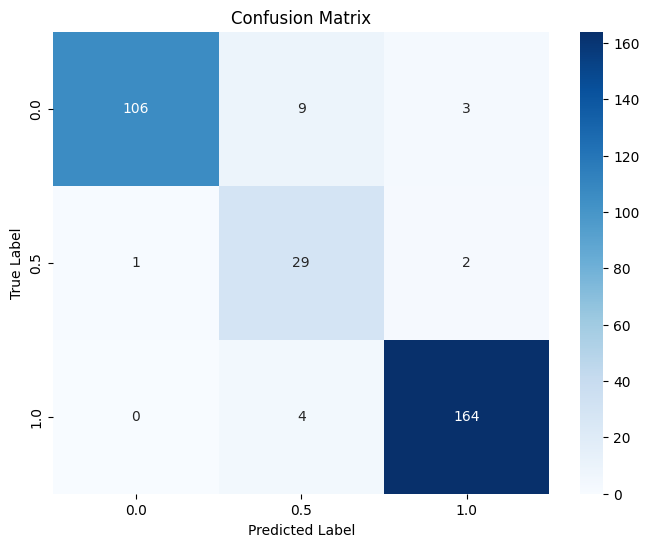


--- Training History Plots ---


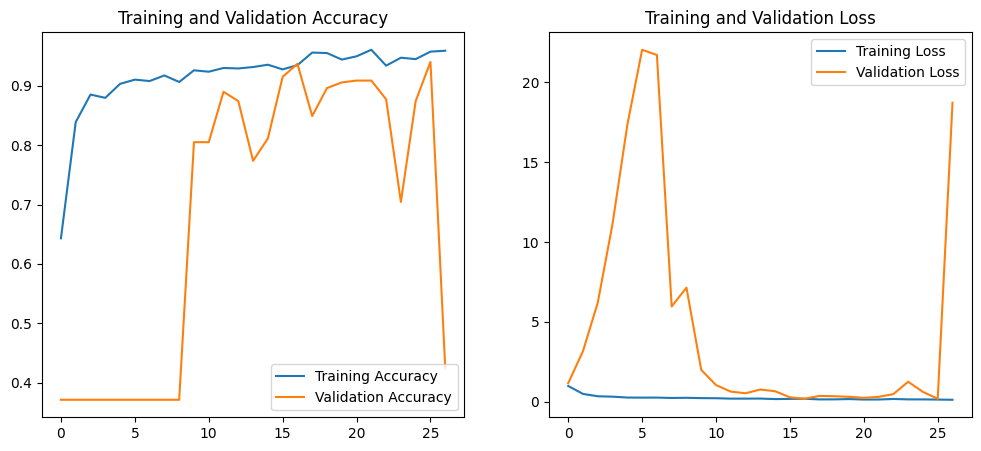

In [12]:
# --- Evaluate the Model ---
print("Evaluating model on test data...")
# Load the best saved model (from the checkpoint) for final evaluation
best_model = tf.keras.models.load_model(MODEL_PATH) 
final_loss, final_accuracy = best_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\n--- Final Test Results ---")
print(f"Final Test Loss: {final_loss:.4f}")
print(f"Final Test Accuracy: {final_accuracy*100:.2f}%")


# --- Generate Classification Report ---
print("\n--- Classification Report ---")
# Get predictions (softmax probabilities)
y_pred_probs = best_model.predict(X_test)
# Convert probabilities to single class labels (e.g., 0, 1, 2, or 3)
y_pred = np.argmax(y_pred_probs, axis=1)

# --- !! NEW FIX HERE !! ---
# Convert class names to strings, just in case they are numbers
target_names_str = [str(name) for name in CLASS_NAMES]
# ---

# 'y_test' is our true numeric labels (0, 1, 2, 3)
# 'y_pred' is our predicted numeric labels
# Use the new 'target_names_str' variable
print(classification_report(y_test, y_pred, target_names=target_names_str))


# --- Generate Confusion Matrix ---
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
# Use the new 'target_names_str' variable here too
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names_str,
            yticklabels=target_names_str)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


# --- Plot Training History ---
# (This uses 'history' from the Cell 4)
print("\n--- Training History Plots ---")
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()